# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Emmanuel Nkunim Amoah Owusu-Marfo
**Student ID:** 35622028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [14]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

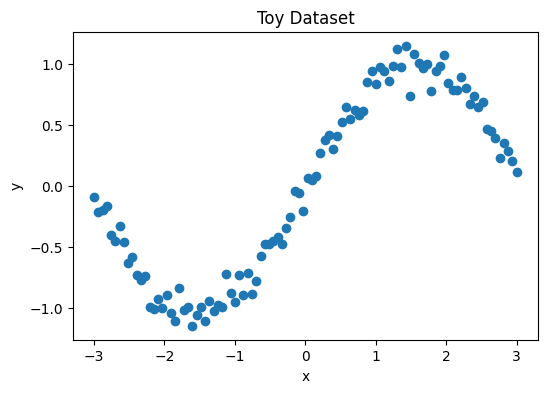

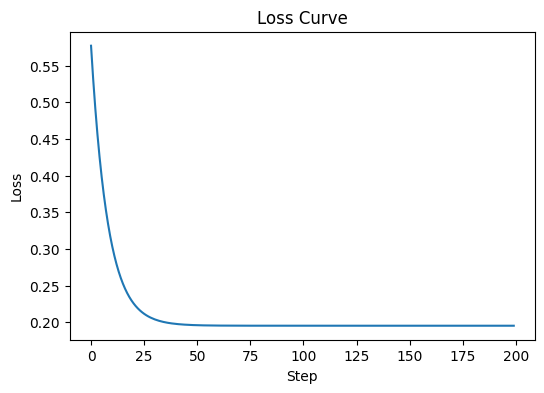

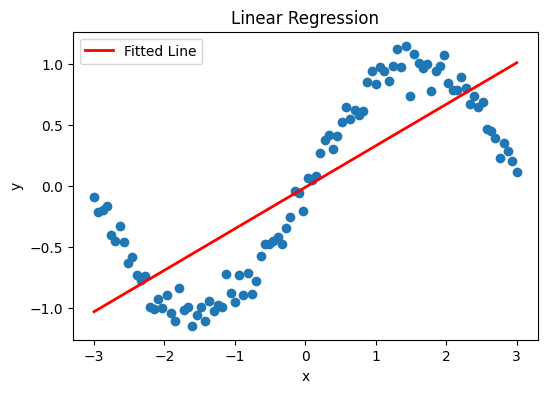

In [15]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3,3,100)
y = np.sin(x) + np.random.normal(0,0.1,size=x.shape)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Dataset")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
lr = 0.01
losses = []

for step in range(200):

    # Predictions
    y_hat = w * x + b

    # Mean Squared Error
    loss = np.mean((y_hat - y) ** 2)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update parameters
    w -= lr * dw
    b -= lr * db

    # Save the loss
    losses.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

y_pred = w * x + b

plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x,y_pred, color="red",linewidth=2,label="Fitted Line")
plt.title("Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

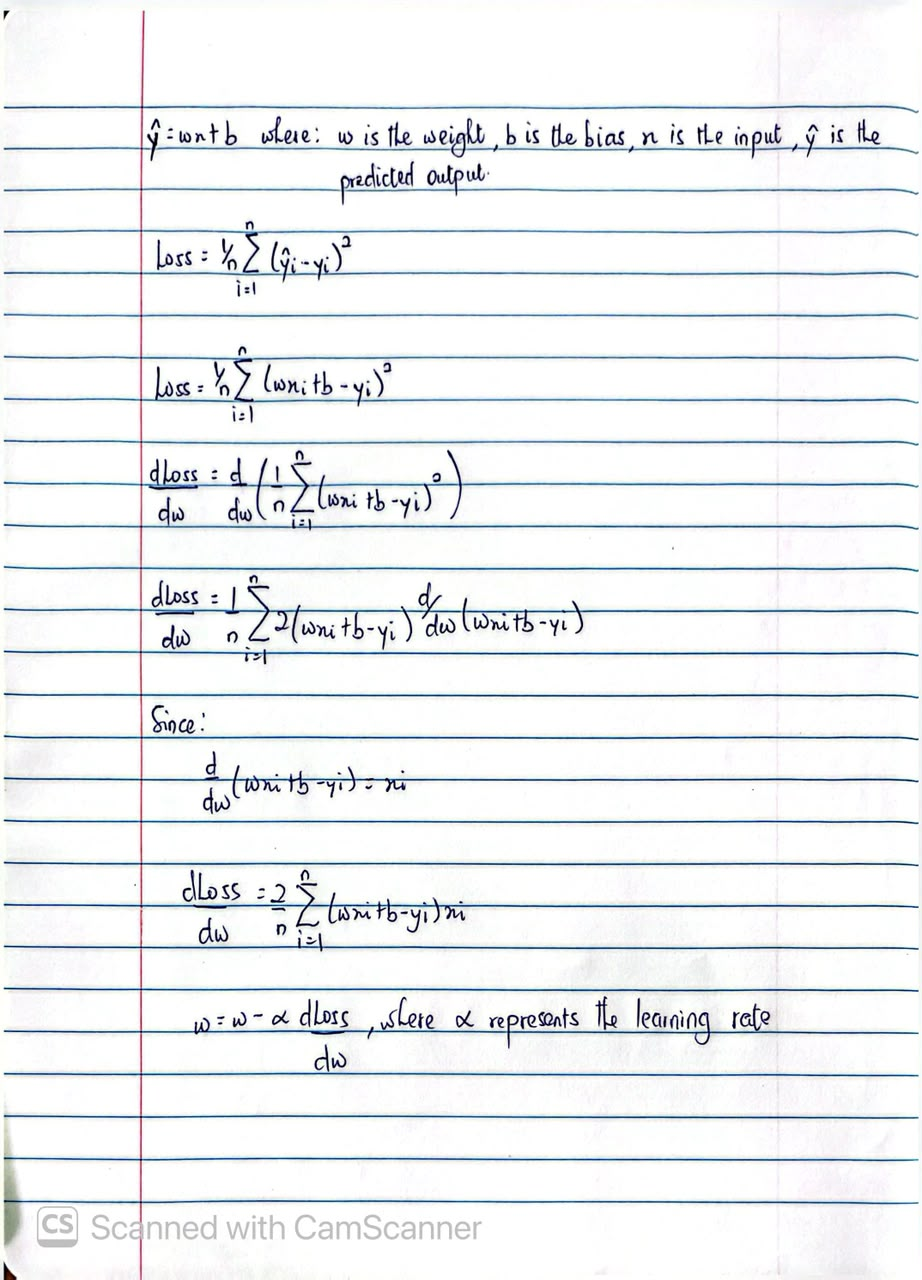
> **Answer:*By comparing the mathematical derivation with the code implementation, we can see that they are equivalent. The model is underfitting because a single neuron is too simple to learn the sine wave pattern.A single neuron can only create a straight line: y = wx + b
while a sine wave is nonlinear: y=sin(x)
Training for longer will not improve the result because the model has already reached the best linear approximation it can make. To fit a sine wave, a more complex model with hidden layers and nonlinear activation functions is needed.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

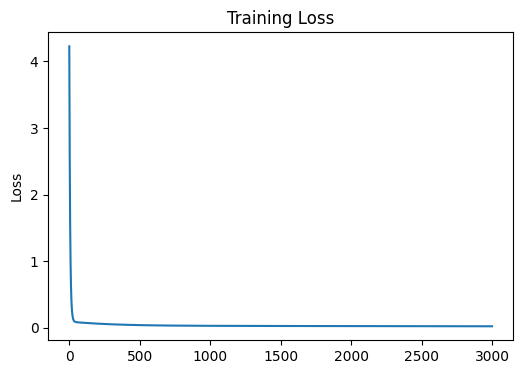

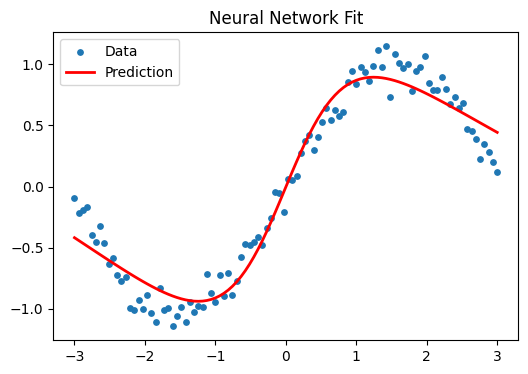

In [16]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

W1 =  np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 =  np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
lr = 0.01
losses = []


for i in range(3000):
  z1 = x @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data", s=15)
plt.plot(x, y_hat, color="red", linewidth=2, label="Prediction")
plt.legend()
plt.title("Neural Network Fit")
plt.show()

# Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
h = z1
dz1 = dh



**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. Because the overall function is still linear, the network cannot learn nonlinear patterns such as a sine wave, regardless of how many linear layers are stacked or how long the model is trained.
2. The 8 hidden neurons each learned a different nonlinear transformation of the input through the tanh activation function. Together, these transformed features were combined by the output layer to approximate the sine wave. The network combined multiple non-linear features to model the curved shape of the date instead of fitting it into one straight line.
3. Backpropagation is the process of computing the gradients of the loss with respect to every weight in the network using the chain rule, allowing the weights to be updated to minimize the loss.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1556/3780134122.py:20: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_1556/3780134122.py:29: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_1556/3780134122.py:30: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


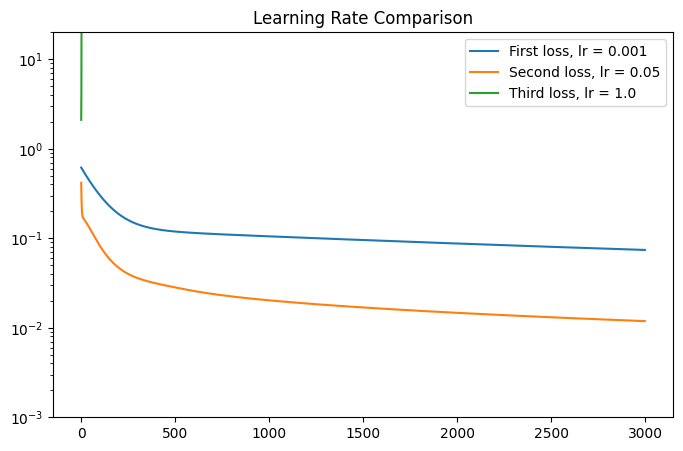

In [17]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for i in range(steps):

        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update parameters
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses



# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
loss_1 = train_toy(0.001,3000)
loss_2 = train_toy(0.05,3000)
loss_3 = train_toy(1.0,3000)
loss_3_clean = np.nan_to_num(loss_3, nan=1e10)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8,5))

plt.plot(loss_1, label="First loss, lr = 0.001")
plt.plot(loss_2, label="Second loss, lr = 0.05")
plt.plot(loss_3, label="Third loss, lr = 1.0")

plt.yscale("log")
plt.ylim(1e-3,20)
plt.title("Learning Rate Comparison")
plt.legend()

plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**
Learning rate = 0.001: The loss decreases slowly because the weight updates are very small. The model learns gradually and may require many more epochs to converge.
Learning rate = 0.05: The loss decreases rapidly and then levels off at a low value. This learning rate provides stable and efficient convergence, allowing the model to reach a good solution.
Learning rate = 1.0: The loss increases instead of decreasing. The updates are too large, preventing the model from converging to the minimum loss.
A large learning rate makes the weight updates too big, causing the model to overshoot the minimum loss. Instead of moving steadily toward the optimum, the weights keep jumping past it, making the loss diverge instead of converging.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from torch.utils.data import TensorDataset, DataLoader

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

obesity["Gender"] = LabelEncoder().fit_transform(obesity["Gender"])
obesity["CAEC"] = LabelEncoder().fit_transform(obesity["CAEC"])
obesity["CALC"] = LabelEncoder().fit_transform(obesity["CALC"])
obesity["MTRANS"] = LabelEncoder().fit_transform(obesity["MTRANS"])

target_encoder = LabelEncoder()
obesity["NObeyesdad"] = target_encoder.fit_transform(obesity["NObeyesdad"])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**
1. CrossEntropyLoss expects each target to be an integer class index. It uses these indices to identify the correst class directly, making the computation more efficient than using one-hot encoded vectors.
2. Neural networks use gradients to update weights, and the gradients depend on the input features. If features have very different scales, some gradients become much larger than others, making training slow.
3. shuffle = True randomly changes the order of the training data at the start of each epoch.This prevents the model from learning patterns based on the order of the data and generally improves learning and generalization.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [19]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self,x):
        return self.net(x)

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train.shape[1]
model = FeedForwardNet(input_dim).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {n_params}")


# Verify first layer parameter count by hand
first_layer_params = input_dim * 64 + 64

print(f"First layer parameters (by hand): {first_layer_params}")

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3399
First layer parameters (by hand): 1088


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
1.
First layer: (16 × 64) + 64 = 1024 + 64 = 1088

Second layer: (64 × 32) + 32 = 2048 + 32 = 2080

Output layer: (32 × 7) + 7 = 224 + 7 = 231

Total parameters: 1088 + 2080 + 231 = 3399

2. ReLU reduces the vanishing gradient problem and usually trains faster.

3. Without ReLU, every layer is treated as linear so the network becomes equivalent to a single linear transformation.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01 | Train Loss: 1.7570 | Train Acc: 0.4937 | Val Loss: 1.7549 | Val Acc: 0.4905
Epoch 02 | Train Loss: 1.4225 | Train Acc: 0.6074 | Val Loss: 1.4260 | Val Acc: 0.6114
Epoch 03 | Train Loss: 1.0394 | Train Acc: 0.6730 | Val Loss: 1.0541 | Val Acc: 0.6564
Epoch 04 | Train Loss: 0.8383 | Train Acc: 0.7164 | Val Loss: 0.8682 | Val Acc: 0.6919
Epoch 05 | Train Loss: 0.7114 | Train Acc: 0.7773 | Val Loss: 0.7661 | Val Acc: 0.7393
Epoch 06 | Train Loss: 0.6145 | Train Acc: 0.8120 | Val Loss: 0.6912 | Val Acc: 0.7749
Epoch 07 | Train Loss: 0.5342 | Train Acc: 0.8507 | Val Loss: 0.6261 | Val Acc: 0.7891
Epoch 08 | Train Loss: 0.4659 | Train Acc: 0.8728 | Val Loss: 0.5702 | Val Acc: 0.8152
Epoch 09 | Train Loss: 0.4121 | Train Acc: 0.8791 | Val Loss: 0.5255 | Val Acc: 0.8270
Epoch 10 | Train Loss: 0.3668 | Train Acc: 0.8910 | Val Loss: 0.4894 | Val Acc: 0.8294
Epoch 11 | Train Loss: 0.3271 | Train Acc: 0.9155 | Val Loss: 0.4634 | Val Acc: 0.8555
Epoch 12 | Train Loss: 0.2923 | Train Acc: 

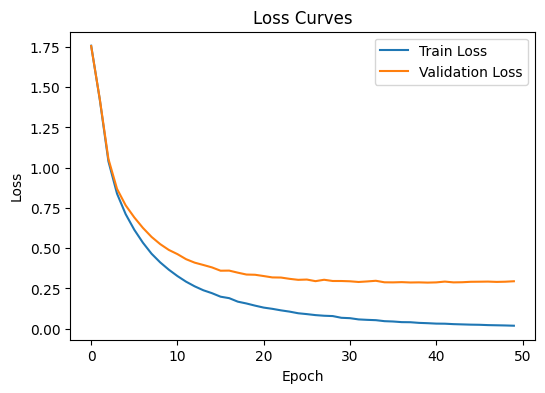

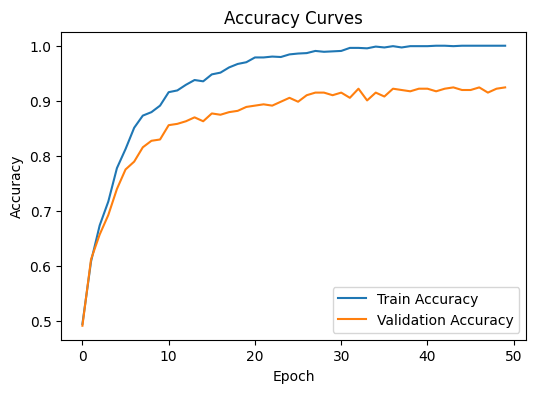

In [20]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
train_losses,val_losses = [],[]
train_accs,val_accs = [],[]

best_val_acc = 0
for epoch in range(50):
  model.train()

  for xb, yb in train_loader:
    xb,yb= xb.to(DEVICE), yb.to(DEVICE)
    optimizer.zero_grad()
    logits = model(xb)
    loss = criterion(logits, yb)
    loss.backward()
    optimizer.step()

  model.eval()

  train_loss = 0.0
  train_correct = 0
  train_total = 0

  val_loss = 0.0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for xb, yb in train_loader:
      xb,yb= xb.to(DEVICE), yb.to(DEVICE)
      logits = model(xb)
      loss = criterion(logits, yb)

      train_loss += loss.item() * xb.size(0)

      preds = logits.argmax(dim=1)
      train_correct += (preds == yb).sum().item()
      train_total += yb.size(0)

    for xb, yb in val_loader:
      xb, yb = xb.to(DEVICE), yb.to(DEVICE)

      logits = model(xb)
      loss = criterion(logits, yb)

      val_loss += loss.item() * xb.size(0)

      preds = logits.argmax(dim=1)
      val_correct += (preds == yb).sum().item()
      val_total += yb.size(0)

  train_loss /= train_total
  val_loss /= val_total

  train_acc = train_correct / train_total
  val_acc = val_correct / val_total

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  train_accs.append(train_acc)
  val_accs.append(val_acc)

  print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )



# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
  if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**
1. Forward pass: logits = model(xb) corresponds to the NumPy forward pass (z1, h, y_hat).

Loss computation: loss = criterion(logits, yb) corresponds to loss = np.mean((y_hat - y)**2).

Gradient computation: loss.backward() corresponds to manually computing dW1, db1, dW2, and db2 using backpropagation.

Parameter update: optimizer.step() corresponds to the NumPy update rules such as W1 -= lr * dW1 and W2 -= lr * dW2.


2. The model shows overfitting. At Epoch 50, the training loss is 0.0189 and the training accuracy is 1.0000 (100%), while the validation loss is 0.2950 and the validation accuracy is 0.9242 (92.42%). The model performs perfectly on the training data but noticeably worse on the validation data, indicating that it has learned the training set very well and is beginning to overfit rather than generalize perfectly.

3. We call optimizer.zero_grad() every batch because PyTorch accumulates gradients by default. Without it, gradients from previous batches are added to the current batch’s gradients, causing incorrect weight updates and potentially unstable training.


### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

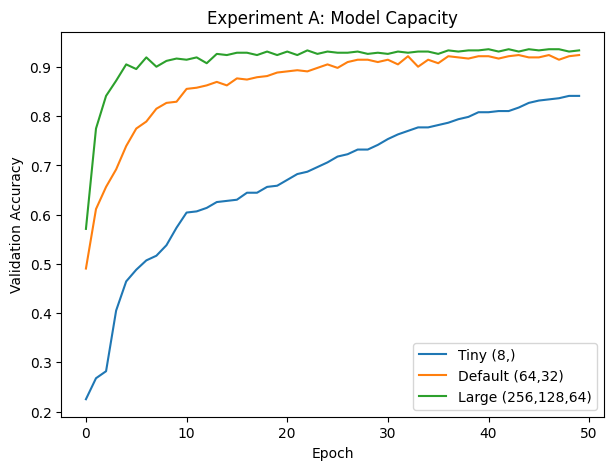

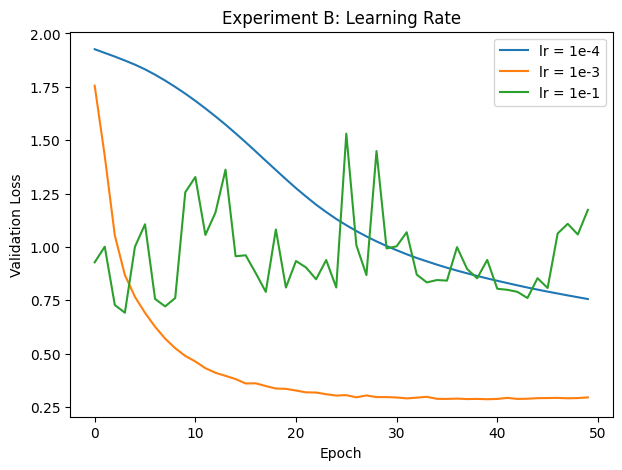

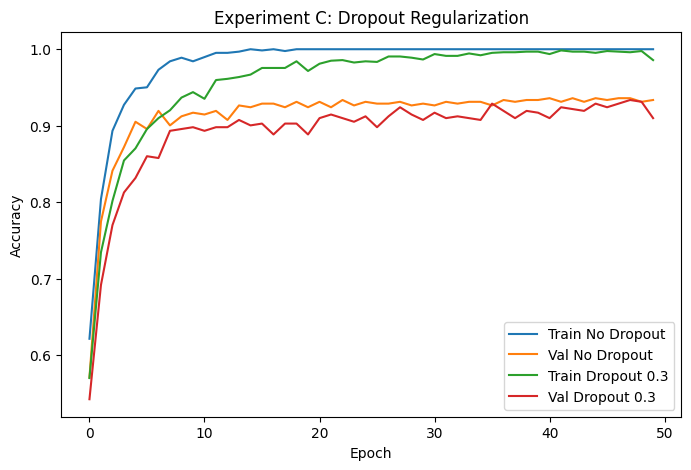

In [23]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []
        in_dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_dim = h

        layers.append(nn.Linear(in_dim, n_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_experiment(hidden_sizes=(64, 32),
                   lr=1e-3,
                   batch_size=32,
                   epochs=50,
                   dropout=0.0):

    torch.manual_seed(42)

    train_loader_exp = DataLoader(train_dataset,
                                  batch_size=batch_size,
                                  shuffle=True)

    val_loader_exp = DataLoader(val_dataset,
                                batch_size=batch_size,
                                shuffle=False)

    model = FeedForwardNet(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        # Train
        model.train()

        for xb, yb in train_loader_exp:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

        # Evaluate
        model.eval()

        train_loss = train_correct = train_total = 0
        val_loss = val_correct = val_total = 0

        with torch.no_grad():

            for xb, yb in train_loader_exp:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)

                train_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)

                train_correct += (preds == yb).sum().item()
                train_total += yb.size(0)

            for xb, yb in val_loader_exp:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)

                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)

        history["train_loss"].append(train_loss / train_total)
        history["val_loss"].append(val_loss / val_total)

        history["train_acc"].append(train_correct / train_total)
        history["val_acc"].append(val_correct / val_total)

    return history



# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
tiny_hist = run_experiment(hidden_sizes=(8,))
default_hist = run_experiment(hidden_sizes=(64, 32))
large_hist = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(7,5))

plt.plot(tiny_hist["val_acc"], label="Tiny (8,)")
plt.plot(default_hist["val_acc"], label="Default (64,32)")
plt.plot(large_hist["val_acc"], label="Large (256,128,64)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Model Capacity")
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
lr1_hist = run_experiment(lr=1e-4)
lr2_hist = run_experiment(lr=1e-3)
lr3_hist = run_experiment(lr=1e-1)

plt.figure(figsize=(7,5))

plt.plot(lr1_hist["val_loss"], label="lr = 1e-4")
plt.plot(lr2_hist["val_loss"], label="lr = 1e-3")
plt.plot(lr3_hist["val_loss"], label="lr = 1e-1")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate")
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
no_dropout_hist = run_experiment(
    hidden_sizes=(256, 128, 64),
    dropout=0.0
)

dropout_hist = run_experiment(
    hidden_sizes=(256, 128, 64),
    dropout=0.3
)

plt.figure(figsize=(8,5))

plt.plot(no_dropout_hist["train_acc"], label="Train No Dropout")
plt.plot(no_dropout_hist["val_acc"], label="Val No Dropout")

plt.plot(dropout_hist["train_acc"], label="Train Dropout 0.3")
plt.plot(dropout_hist["val_acc"], label="Val Dropout 0.3")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C: Dropout Regularization")
plt.legend()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:**
1. Capacity: The largest network did not necessarily win on validation accuracy. After a certain model size, validation accuracy improved only slightly or stopped improving, while training accuracy continued to increase, indicating diminishing returns and mild overfitting.
2. Learning rate: Yes. The three learning-rate regimes matched the toy problem in Part 1.3: 1e-4 learned slowly, 1e-3 converged well, and 1e-1 was unstable and showed oscillation or poor convergence.
3. Regularization: Dropout reduced the gap between training and validation accuracy, usually by lowering training accuracy slightly while improving validation performance.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [22]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.